# 02 — RAG-Assisted Label Cleaning for MAVE Laptops NER

# Part 1 - Theoretical Background

## 1) The Label Noise Problem

The EDA (Notebook 01) identified systematic annotation inconsistencies in the MAVE Laptops dataset that directly limit model performance. Three distinct pathologies were observed:

- **Token-level ambiguity**: 1,495 tokens appear under more than one entity class across training sequences. For instance, `"intel"` is annotated as `BRAND`, `PROCESSOR`, `RESOLUTION`, and `SCREEN_SIZE` in different examples — a contradictory supervision signal for the same surface form.
- **Cross-class span overlap**: 230 entity values appear as both `BRAND` and `PROCESSOR` spans across different sequences, confirming that the inconsistency extends beyond individual tokens to full entity spans.
- **Boundary inconsistency**: the same surface form (e.g. *Intel Core i7*) is sometimes annotated as a single `PROCESSOR` span and sometimes split into `BRAND` + `PROCESSOR`, producing conflicting boundary decisions for identical input.

These issues constitute **label noise** as defined by Frenay & Verleysen (2014): contradictory supervision signals prevent the model from learning stable decision boundaries, directly depressing F1 on affected classes — particularly `BRAND`, which showed the highest overlap with other classes in the EDA.

## 2) Retrieval-Augmented Generation (RAG)

Large Language Models encode world knowledge in their parameters during pre-training — this is referred to as **parametric memory**. For a label cleaning task, parametric memory alone has two critical limitations: the LLM has no knowledge of dataset-specific annotation conventions, and it may assign labels based on general semantics rather than on the conventions observed in the data (e.g. treating `"intel"` as a company brand rather than as part of a `PROCESSOR` span).

**Retrieval-Augmented Generation** (Lewis et al., 2020) addresses both limitations by augmenting the prompt with evidence retrieved from an external **non-parametric memory** source. Unlike the original RAG formulation, which uses a dense neural retriever, we adopt TF-IDF sparse retrieval — better suited to the short, domain-specific vocabulary of product titles where lexical overlap between query and relevant documents is high. The pipeline follows three steps:

$$\text{RAG} = \underbrace{\text{Retrieve}(q, \mathcal{K})}_{\text{top-}k\text{ evidence}} \rightarrow \underbrace{\text{Augment}(q, \text{context})}_{\text{grounded prompt}} \rightarrow \underbrace{\text{Generate}(\text{prompt})}_{\text{LLM decision}}$$

where the query $q$ is the ambiguous span with its local context, and the knowledge base $\mathcal{K}$ is the trusted corpus. Grounding the prompt with retrieved examples constrains the LLM to follow annotation conventions actually observed in the data, rather than relying on general semantic intuitions.  

The distinction between the two memory types is important: parametric memory is encoded in the model weights during pre-training and cannot be updated at inference time without retraining. Non-parametric memory, by contrast, is an external corpus that can be queried dynamically — in our case, the trusted corpus derived from the training split, which encodes the specific annotation conventions of the MAVE dataset.

## 3) TF-IDF Retrieval

Retrieval is performed using **TF-IDF cosine similarity**. The TF-IDF weight of term $t$ in document $d$ is defined as:

$$\text{tfidf}(t, d) = \frac{f_{t,d}}{\sum_{t'} f_{t',d}} \times \log \frac{|D|}{|\{d' : t \in d'\}|}$$

where the first factor measures the local frequency of $t$ in $d$ (term frequency) and the second penalises terms that appear in many documents (inverse document frequency). Documents are then ranked by cosine similarity to the query:

$$\text{sim}(q, d) = \frac{\mathbf{q} \cdot \mathbf{d}}{\|\mathbf{q}\| \cdot \|\mathbf{d}\|}$$

TF-IDF is well-suited to this setting because product titles are short, domain-specific, and share a compact vocabulary — the conditions under which sparse retrieval is competitive with dense embedding approaches. One index is built **per entity class** to prevent cross-class retrieval contamination. Without this separation, a query for a `BRAND`/`PROCESSOR` ambiguity could retrieve sequences where the same token is annotated as `BRAND` — reinforcing the very error the pipeline is trying to correct, rather than providing evidence for the correct label.

In practice, sublinear term frequency scaling is applied ($1 + \log f_{t,d}$ in place of the raw count), which reduces the impact of very frequent terms within a single document and is standard practice for short-text retrieval.

## 4) Prompt Design: Few-Shot and Chain-of-Thought

The grounded prompt follows standard prompt engineering principles (Brown et al., 2020):

- **Persona**: the model is instructed to act as an expert NER annotator for laptop product titles
- **Instruction**: assign the single most consistent label for the ambiguous span, following the conventions observed in the retrieved examples
- **Few-shot context**: the top-$k$ retrieved examples provide in-context demonstrations of correct annotations for the candidate class
- **Hard constraints**: disambiguation rules derived directly from EDA findings (e.g. processor architecture tokens such as `"core"`, `"i5"`, `"ghz"` should never be labelled `BRAND`)
- **Chain-of-Thought output**: the response includes both a `label` field and a `reasoning` field, encouraging the model to make its decision process explicit before committing to a label

`temperature=0.0` is set throughout to ensure deterministic and reproducible output, consistent with the annotation cleaning objective.

## 5) Rule-First Strategy

Not every ambiguous span requires LLM inference. Where EDA provides unambiguous deterministic evidence, a hard rule resolves the span at zero API cost. The pipeline therefore follows a **rule-first strategy**:

1. **Deterministic rules** handle unambiguous cases instantly — high precision, no API calls
2. **RAG + LLM fallback** is invoked only for genuinely ambiguous spans where in-domain evidence is needed to make a defensible decision

This design is more efficient, more robust to API failures, and more methodologically transparent: the LLM is used only where it adds real value over a rule.

## 6) Evaluation Settings

Cleaning only the training split is the most rigorous setup for downstream evaluation, since it avoids any form of test-time relabelling. However, because the original validation and test labels are also noisy, gains measured on the original test set may underestimate the true benefit of annotation refinement.

Two evaluation settings are therefore adopted:

**Setting 1 — Main benchmark:** the model is trained on cleaned training data and evaluated on the original, untouched test set. This is the primary benchmark — any improvement measured here is conservative but fully defensible.

**Setting 2 — Auxiliary noise-aware analysis:** both training and evaluation are performed on cleaned data. This setting is used to estimate how much improvement is hidden by residual noise in the original test labels. Validation and test splits are cleaned using the trusted corpus built exclusively from the training split, so no test-distribution information enters the retrieval process.

If gains in Setting 1 are modest, the correct interpretation is that they are likely underestimated — the auxiliary setting provides the complementary evidence.

# Part 2 - Pipeline Implementation

## 7) Imports and Configuration

The pipeline depends on `scikit-learn` for TF-IDF retrieval, `requests` for Groq API calls, and standard Python libraries for data handling. All entity-specific colours follow the Okabe-Ito colorblind-safe palette used consistently throughout the project.

The key hyperparameters are:
- `TOP_K = 5`: number of support examples retrieved per ambiguous span — a standard few-shot context size, small enough to fit within the prompt without exceeding the model's context window
- `MIN_TRUST_FREQ = 3`: minimum frequency for a token to enter the programmatic trusted corpus — filters out hapax legomena and near-unique surface forms that would introduce noise into the retrieval index
- `INTER_REQUEST_SLEEP = 2.0`: rate-limiting delay between API calls, required by the Groq paid tier to avoid throttling

In [7]:
import json
import os
import re
import sys
import time
import random
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from getpass import getpass


# ── Okabe-Ito colorblind-safe palette ──────────────────────────────────────
COLORS = {
    'BRAND':       '#56B4E9',
    'SCREEN_SIZE': '#E69F00',
    'PROCESSOR':   '#009E73',
    'RESOLUTION':  '#CC79A7',
    'BATTERY':     '#0072B2',
    'clean':       '#009E73',
    'noisy':       '#D55E00',
}

ENTITY_CLASSES = ['BRAND', 'SCREEN_SIZE', 'PROCESSOR', 'RESOLUTION', 'BATTERY']
BIO_LABELS     = ['O'] + [f'B-{e}' for e in ENTITY_CLASSES] + [f'I-{e}' for e in ENTITY_CLASSES]

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR         = '/Users/asiagrillo/Desktop/MAVE/'
TRAIN_PATH       = os.path.join(DATA_DIR, 'laptops_train.jsonl')
VAL_PATH         = os.path.join(DATA_DIR, 'laptops_val.jsonl')
TEST_PATH        = os.path.join(DATA_DIR, 'laptops_test.jsonl')
CLEAN_TRAIN_PATH = os.path.join(DATA_DIR, 'laptops_train_rag_cleaned.jsonl')
CLEAN_VAL_PATH   = os.path.join(DATA_DIR, 'laptops_val_rag_cleaned.jsonl')
CLEAN_TEST_PATH  = os.path.join(DATA_DIR, 'laptops_test_rag_cleaned.jsonl')

# ── Groq API ───────────────────────────────────────────────────────────────
GROQ_API_KEY        = getpass('Groq API key: ')
GROQ_MODEL          = 'llama-3.1-8b-instant'
GROQ_URL            = 'https://api.groq.com/openai/v1/chat/completions'

# ── RAG hyperparameters ────────────────────────────────────────────────────
TOP_K               = 5     # support examples retrieved per ambiguous span
MIN_TRUST_FREQ      = 3     # min token frequency to enter programmatic trusted corpus
INTER_REQUEST_SLEEP = 2.0   # seconds between Groq calls (paid tier)
INTER_SEQ_SLEEP     = 0.5   # extra sleep between sequences

# ── Sampling — set to None to process ALL noisy sequences ─────────────────
N_SAMPLES = None  # set to None for full run

random.seed(42)
np.random.seed(42)

print('Configuration loaded.')
print(f'Entity classes  : {ENTITY_CLASSES}')
print(f'RAG top-K       : {TOP_K}')
print(f'Min trust freq  : {MIN_TRUST_FREQ}')
print(f'N_SAMPLES       : {N_SAMPLES} (None = process all)')
sys.stdout.flush()

Configuration loaded.
Entity classes  : ['BRAND', 'SCREEN_SIZE', 'PROCESSOR', 'RESOLUTION', 'BATTERY']
RAG top-K       : 5
Min trust freq  : 3
N_SAMPLES       : None (None = process all)


## 8) Data Loading

In [3]:
def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

train_data = load_jsonl(TRAIN_PATH)
val_data   = load_jsonl(VAL_PATH)
test_data  = load_jsonl(TEST_PATH)

splits = {'train': train_data, 'val': val_data, 'test': test_data}
clean_paths = {
    'train': CLEAN_TRAIN_PATH,
    'val':   CLEAN_VAL_PATH,
    'test':  CLEAN_TEST_PATH,
}

print(f'Train : {len(train_data):,} sequences')
print(f'Val   : {len(val_data):,} sequences')
print(f'Test  : {len(test_data):,} sequences')
sys.stdout.flush()

Train : 7,479 sequences
Val   : 935 sequences
Test  : 935 sequences


## 9) Core Utilities

In [4]:
def extract_spans(tokens, labels):
    spans, i = [], 0
    while i < len(labels):
        if labels[i].startswith('B-'):
            cls, start, j = labels[i].split('-')[1], i, i + 1
            while j < len(labels) and labels[j] == f'I-{cls}':
                j += 1
            spans.append((start, j, ' '.join(tokens[start:j]).lower(), cls))
            i = j
        else:
            i += 1
    return spans


def local_window(tokens, start, end, w=3):
    return tokens[max(0, start - w):min(len(tokens), end + w)]


def validate_bio(labels):
    prev = None
    for lab in labels:
        if lab not in BIO_LABELS:
            return False
        if lab.startswith('I-') and prev != lab.split('-')[1]:
            return False
        prev = lab.split('-')[1] if lab != 'O' else None
    return True


def apply_span_correction(labels, start, end, new_class):
    """
    Apply a corrected label to one span.
    Only positions [start, end) are modified — all other labels are preserved.
    This ensures that corrections are surgical: no side effects on adjacent spans.
    """
    new_labels = labels[:]
    if new_class == 'O':
        for i in range(start, end):
            new_labels[i] = 'O'
    else:
        new_labels[start] = f'B-{new_class}'
        for i in range(start + 1, end):
            new_labels[i] = f'I-{new_class}'
    return new_labels


print('Core utilities defined.')
sys.stdout.flush()

Core utilities defined.


## 10) Noise Detection

A token is defined as **ambiguous** if the same surface form appears under more than one entity class within a split:

$$\text{ambiguous}(t) = \mathbb{1}\left[\left|\{c \mid \exists\, i : \text{tok}_i = t,\ \text{lab}_i \in \{\text{B-}c, \text{I-}c\}\}\right| > 1\right]$$

A sequence is then classified as **noisy** if at least one of its entity spans has a head token that is ambiguous — i.e. a token whose label assignment cannot be considered reliable based on the training distribution alone. Sequences where no span contains an ambiguous token are classified as **clean** and passed through to the output without modification.

Each split is analysed independently to build a self-contained noise profile. Note that ambiguity is measured within each split separately: a token that is unambiguous in the training set may still appear ambiguous in validation or test due to different annotation contexts.  

Note that ambiguity is assessed on the **head token** of each span — the first token of the surface form. A span such as *"Intel Core i7"* is therefore classified as ambiguous because `"intel"` appears under multiple entity classes in the training data, regardless of whether the full span is unambiguous in context. This is a deliberate simplification: head tokens are the primary carriers of entity identity in technical product titles, and assessing the full span would require exact string matching across the entire vocabulary of surface forms.

In [5]:
def detect_noise(data, split_name):
    token_class_freq = defaultdict(Counter)
    for ex in data:
        for tok, lab in zip(ex['tokens'], ex['labels']):
            if lab != 'O':
                token_class_freq[tok.lower()][lab.split('-')[1]] += 1

    ambiguous_tokens = {t: f for t, f in token_class_freq.items() if len(f) > 1}
    trusted_tokens   = {t: f for t, f in token_class_freq.items() if len(f) == 1}

    noisy_sequences, clean_sequences = [], []
    for ex in data:
        spans = extract_spans(ex['tokens'], ex['labels'])
        ambig = [
            {
                'start':      s,
                'end':        e,
                'surface':    surf,
                'orig_class': cls,
                'candidates': list(ambiguous_tokens[surf.split()[0]].keys())
                              if surf.split() and surf.split()[0] in ambiguous_tokens else [cls],
                'window':     local_window(ex['tokens'], s, e),
            }
            for s, e, surf, cls in spans
            if surf.split() and surf.split()[0] in ambiguous_tokens
        ]
        if ambig:
            noisy_sequences.append({'example': ex, 'ambig_spans': ambig})
        else:
            clean_sequences.append(ex)

    print(f'[{split_name}] Unique non-O tokens     : {len(token_class_freq):,}')
    print(f'[{split_name}] Ambiguous (>=2 classes) : {len(ambiguous_tokens):,}  ({len(ambiguous_tokens)/max(len(token_class_freq),1)*100:.1f}%)')
    print(f'[{split_name}] Noisy sequences         : {len(noisy_sequences):,}  ({len(noisy_sequences)/max(len(data),1)*100:.1f}%)')
    print(f'[{split_name}] Clean sequences         : {len(clean_sequences):,}')
    print()
    return token_class_freq, ambiguous_tokens, trusted_tokens, noisy_sequences, clean_sequences


print('=== Noise Detection per Split ===')
print()
noise_results = {}
for split_name, data in splits.items():
    tcf, amb, tru, noisy, clean = detect_noise(data, split_name)
    noise_results[split_name] = {
        'token_class_freq': tcf, 'ambiguous_tokens': amb,
        'trusted_tokens': tru, 'noisy_sequences': noisy,
        'clean_sequences': clean,
    }
sys.stdout.flush()

=== Noise Detection per Split ===

[train] Unique non-O tokens     : 2,990
[train] Ambiguous (>=2 classes) : 625  (20.9%)
[train] Noisy sequences         : 7,144  (95.5%)
[train] Clean sequences         : 335

[val] Unique non-O tokens     : 800
[val] Ambiguous (>=2 classes) : 165  (20.6%)
[val] Noisy sequences         : 830  (88.8%)
[val] Clean sequences         : 105

[test] Unique non-O tokens     : 827
[test] Ambiguous (>=2 classes) : 150  (18.1%)
[test] Noisy sequences         : 767  (82.0%)
[test] Clean sequences         : 168



Noise is pervasive: 95.5% of training sequences contain at least one ambiguous span, confirming that the annotation inconsistencies identified in the EDA are not isolated but structural. The ambiguous token rate is consistent across splits (20.9% / 20.6% / 18.1%), suggesting that the noise pattern is uniformly distributed rather than concentrated in specific partitions.

Only 335 training sequences (4.5%) are clean under this definition and can be passed through directly. The remaining 7,144 sequences require span-level inspection and potential correction by the pipeline.

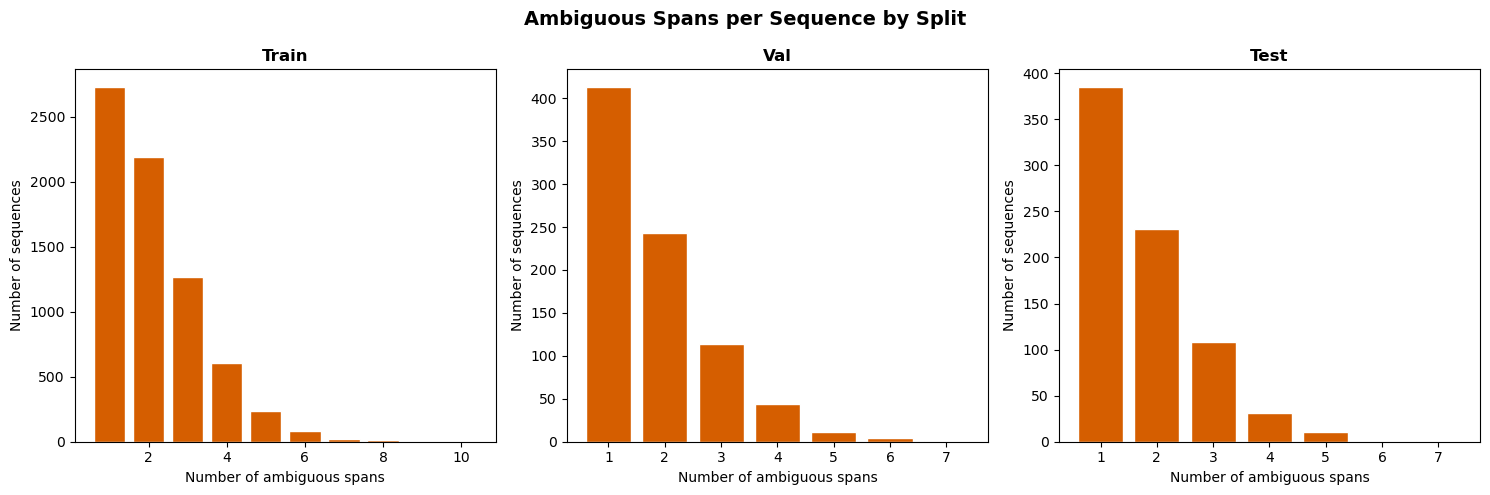

In [ ]:
# ── Visualisation: ambiguous span count distribution per sequence ──────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Ambiguous Spans per Sequence by Split', fontsize=14, fontweight='bold')

for ax, split_name in zip(axes, ['train', 'val', 'test']):
    r = noise_results[split_name]
    # count ambiguous spans per noisy sequence
    ambig_counts = [len(s['ambig_spans']) for s in r['noisy_sequences']]
    counter = Counter(ambig_counts)
    keys = sorted(counter.keys())
    vals = [counter[k] for k in keys]
    ax.bar(keys, vals, color=COLORS['noisy'], edgecolor='white')
    ax.set_title(split_name.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of ambiguous spans')
    ax.set_ylabel('Number of sequences')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('ambiguous_spans_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
sys.stdout.flush()

The distributions are right-skewed across all splits: most noisy sequences contain only 1 or 2 ambiguous spans, while sequences with 5 or more are rare. In the training set, the two largest bars (1 and 2 ambiguous spans) together account for the majority of noisy sequences, suggesting that the cleaning workload is concentrated on a relatively small number of span-level decisions per sequence rather than requiring wholesale relabelling.

This distribution justifies the surgical correction strategy implemented in the pipeline: rather than discarding or rewriting entire sequences, each ambiguous span is resolved independently, leaving all unambiguous labels intact.

## 11) Trusted Corpus Construction

The retrieval index must contain only high-confidence annotations — using the raw dataset as a retrieval source would propagate the same errors the pipeline is trying to correct. The trusted corpus is built from two complementary layers:

**Layer 1 — Programmatic:** spans where the head token appears under exactly one entity class in the split, with a minimum frequency of `MIN_TRUST_FREQ = 3` occurrences, and whose surface form matches a class-specific regex pattern. The frequency threshold filters out hapax legomena and near-unique surface forms that could introduce noise into the index. The regex acts as a hard constraint — a span claiming to be `SCREEN_SIZE` must match a pattern such as `^\d{1,2}\.?\d*[-\s]?(inch|in|")$` to be admitted.

**Layer 2 — Manual seed:** 35 canonical examples covering the most critical ambiguous pairs (`BRAND`/`PROCESSOR` and `SCREEN_SIZE`/`RESOLUTION`) are hardcoded for transparency and reproducibility. These provide a reliable baseline for classes where the programmatic layer produces few trusted entries.

One trusted corpus is built per split. However, for cleaning validation and test sequences, only the **training trusted corpus** is used as the retrieval source — never the split's own corpus. This ensures that no test-distribution information enters the retrieval process, preserving the integrity of the evaluation.

In [ ]:
# ── Manual seed (identical across all splits) ─────────────────────────────
MANUAL_SEED = [
    # BRAND
    ('dell',        'BRAND', 'Dell Inspiron 15 3000 Series Laptop'),
    ('hp',          'BRAND', 'HP Pavilion 15.6 Inch Laptop'),
    ('lenovo',      'BRAND', 'Lenovo ThinkPad T450 14-Inch Laptop'),
    ('asus',        'BRAND', 'Asus VivoBook 15.6 Inch Laptop'),
    ('acer',        'BRAND', 'Acer Aspire E 15 Laptop'),
    ('toshiba',     'BRAND', 'Toshiba Satellite C55 15.6-Inch Laptop'),
    ('samsung',     'BRAND', 'Samsung Chromebook 11.6-Inch Laptop'),
    ('sony',        'BRAND', 'Sony VAIO 14-Inch Laptop'),
    ('apple',       'BRAND', 'Apple MacBook Pro 13-Inch Laptop'),
    ('msi',         'BRAND', 'MSI GL62M 15.6 Gaming Laptop'),
    # PROCESSOR
    ('intel core i3', 'PROCESSOR', 'Dell Inspiron Intel Core i3-5005U 15.6-Inch Laptop'),
    ('intel core i5', 'PROCESSOR', 'Lenovo IdeaPad Intel Core i5-6200U 14-Inch Laptop'),
    ('intel core i7', 'PROCESSOR', 'Asus ZenBook Intel Core i7-7500U 13.3-Inch Laptop'),
    ('intel pentium', 'PROCESSOR', 'Acer Aspire Intel Pentium N3700 15.6-Inch Laptop'),
    ('intel celeron', 'PROCESSOR', 'HP Stream Intel Celeron N3060 11.6-Inch Laptop'),
    ('amd a6',        'PROCESSOR', 'HP AMD A6-7310 15.6-Inch Laptop'),
    ('amd a8',        'PROCESSOR', 'Lenovo AMD A8-7410 15.6-Inch Laptop'),
    ('amd a10',       'PROCESSOR', 'Asus AMD A10-8700P 15.6-Inch Laptop'),
    ('amd e1',        'PROCESSOR', 'Acer AMD E1-7010 11.6-Inch Laptop'),
    ('amd ryzen 5',   'PROCESSOR', 'HP Pavilion AMD Ryzen 5 15.6-Inch Laptop'),
    # SCREEN_SIZE
    ('11.6-inch', 'SCREEN_SIZE', 'Acer Chromebook 11.6-Inch Laptop'),
    ('13.3-inch', 'SCREEN_SIZE', 'Asus ZenBook 13.3-Inch Ultrabook Laptop'),
    ('14-inch',   'SCREEN_SIZE', 'Lenovo ThinkPad 14-Inch Laptop'),
    ('15.6-inch', 'SCREEN_SIZE', 'Dell Inspiron 15.6-Inch Laptop'),
    ('17.3-inch', 'SCREEN_SIZE', 'HP Envy 17.3-Inch Laptop'),
    # RESOLUTION
    ('1920x1080', 'RESOLUTION', 'Dell XPS 15.6-Inch 1920x1080 Full HD Laptop'),
    ('1366x768',  'RESOLUTION', 'Acer Aspire 15.6-Inch 1366x768 HD Laptop'),
    ('1280x800',  'RESOLUTION', 'Toshiba Satellite 13.3-Inch 1280x800 Laptop'),
    ('full hd',   'RESOLUTION', 'Lenovo IdeaPad Full HD 15.6-Inch Laptop'),
    ('fhd',       'RESOLUTION', 'Asus VivoBook FHD 15.6-Inch Laptop'),
    # BATTERY
    ('6-cell',    'BATTERY', 'Lenovo ThinkPad 6-Cell Battery 14-Inch Laptop'),
    ('4-cell',    'BATTERY', 'Dell Inspiron 4-Cell Battery 15.6-Inch Laptop'),
    ('9-cell',    'BATTERY', 'HP EliteBook 9-Cell Battery 14-Inch Laptop'),
    ('4400mah',   'BATTERY', 'Acer Aspire 4400mAh Battery 15.6-Inch Laptop'),
    ('6600mah',   'BATTERY', 'Toshiba Satellite 6600mAh Battery 15.6-Inch Laptop'),
]

# ── Class-specific regex patterns (hard constraints) ──────────────────────
CLASS_REGEX = {
    'SCREEN_SIZE': re.compile(r'^(\d{1,2}\.?\d*)[-\s]?(inch|in|")$', re.IGNORECASE),
    'RESOLUTION':  re.compile(r'^(\d{3,4}x\d{3,4}|full[\s-]?hd|fhd|hd|qhd|uhd|4k)$', re.IGNORECASE),
    'BATTERY':     re.compile(r'^(\d[-\s]?cell|\d{4,5}mah|\d+wh)$', re.IGNORECASE),
    'PROCESSOR':   re.compile(r'^(intel|amd|qualcomm|celeron|pentium|ryzen|core[-\s]?i[3579])', re.IGNORECASE),
    'BRAND':       None,
}

def passes_regex(surface, cls):
    pattern = CLASS_REGEX.get(cls)
    if pattern is None:
        return True
    return bool(pattern.match(surface.strip()))


def build_trusted_corpus(data, split_name, token_class_freq, ambiguous_tokens):
    corpus = []
    # Layer 1: programmatic
    for ex in data:
        title = ' '.join(ex['tokens'])
        for start, end, surface, cls in extract_spans(ex['tokens'], ex['labels']):
            head = surface.split()[0]
            if (head not in ambiguous_tokens
                    and token_class_freq[head].get(cls, 0) >= MIN_TRUST_FREQ
                    and passes_regex(surface, cls)):
                corpus.append({'surface': surface, 'cls': cls, 'title': title, 'source': 'programmatic'})
    # Layer 2: manual seed
    for surface, cls, title in MANUAL_SEED:
        corpus.append({'surface': surface, 'cls': cls, 'title': title, 'source': 'manual_seed'})

    src = Counter(e['source'] for e in corpus)
    cls_cnt = Counter(e['cls'] for e in corpus)
    print(f'[{split_name}] Trusted corpus: {len(corpus):,} entries  '
          f'(programmatic={src["programmatic"]}, seed={src["manual_seed"]})')
    for c in ENTITY_CLASSES:
        print(f'  {c:12s}: {cls_cnt[c]:,}')
    print()
    return corpus


print('=== Building Trusted Corpora ===')
print()
trusted_corpora = {}
for split_name, data in splits.items():
    r = noise_results[split_name]
    trusted_corpora[split_name] = build_trusted_corpus(
        data, split_name, r['token_class_freq'], r['ambiguous_tokens']
    )
sys.stdout.flush()

=== Building Trusted Corpora ===

[train] Trusted corpus: 548 entries  (programmatic=513, seed=35)
  BRAND       : 151
  SCREEN_SIZE : 355
  PROCESSOR   : 10
  RESOLUTION  : 27
  BATTERY     : 5

[val] Trusted corpus: 257 entries  (programmatic=222, seed=35)
  BRAND       : 75
  SCREEN_SIZE : 155
  PROCESSOR   : 10
  RESOLUTION  : 12
  BATTERY     : 5

[test] Trusted corpus: 328 entries  (programmatic=293, seed=35)
  BRAND       : 39
  SCREEN_SIZE : 269
  PROCESSOR   : 10
  RESOLUTION  : 5
  BATTERY     : 5



The corpus is dominated by `SCREEN_SIZE` entries (355 in train), which is expected: screen size expressions have a compact and highly regular surface form that the regex confirms with high precision. `PROCESSOR` (10 entries) and `BATTERY` (5 entries) are underrepresented in the programmatic layer because their surface forms are more variable and frequently appear among ambiguous tokens — exactly the tokens excluded by the trusted corpus filter. The manual seed compensates partially, but the low support for these classes means that RAG evidence for `PROCESSOR` and `BATTERY` ambiguities will rely more heavily on the seed examples than on programmatically extracted ones.

## 12) TF-IDF Retrieval Index

One TF-IDF index is built per entity class using the training trusted corpus. The vectorizer uses bigrams (`ngram_range=(1, 2)`) in addition to unigrams to capture multi-word patterns that are semantically meaningful in product titles — for example, `"core i5"` or `"15.6 inch"` are more informative as bigrams than as individual tokens. Sublinear term frequency scaling (`sublinear_tf=True`) is applied as discussed in Section 1.3.

The retrieval query is **span-centred**: it combines the full product title (global context), the ambiguous surface form (exact-match signal), and the local ±3-token window (immediate syntactic context). This multi-granularity query design ensures that the retriever can match both on the specific surface form and on the broader product context.

Crucially, the same retriever — built from the training trusted corpus — is used for all three splits. Validation and test sequences are never used to build or augment the retrieval index, so no test-distribution information enters the retrieval process at any point.

In [ ]:
class TFIDFRetriever:
    """
    Per-class TF-IDF retriever over a trusted corpus.
    One vectorizer per entity class — prevents cross-class contamination.
    Query is span-centered: title + surface + local window.
    """
    def __init__(self, corpus):
        self.vectorizers, self.matrices, self.entries = {}, {}, {}
        for cls in ENTITY_CLASSES:
            cls_entries = [e for e in corpus if e['cls'] == cls]
            if not cls_entries:
                continue
            vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1, sublinear_tf=True)
            mat = vec.fit_transform([e['title'] for e in cls_entries])
            self.vectorizers[cls] = vec
            self.matrices[cls]    = mat
            self.entries[cls]     = cls_entries

    def retrieve(self, query_text, cls, top_k=TOP_K):
        if cls not in self.vectorizers:
            return []
        q_vec = self.vectorizers[cls].transform([query_text])
        sims  = cosine_similarity(q_vec, self.matrices[cls]).flatten()
        top_idx = sims.argsort()[::-1][:top_k]
        return [(self.entries[cls][i], float(sims[i])) for i in top_idx if sims[i] > 0]


# Build trusted corpus from train only
# Val and test use the train retriever — no information from val/test
# enters the retrieval process, keeping the test set truly external.
print('Building TF-IDF index from train corpus only...', end=' ')
sys.stdout.flush()
train_trusted_corpus = trusted_corpora['train']
retriever_from_train = TFIDFRetriever(train_trusted_corpus)
print('done.')
for cls in ENTITY_CLASSES:
    n = len(retriever_from_train.entries.get(cls, []))
    print(f'  {cls:12s}: {n:,} indexed entries')
sys.stdout.flush()

Building TF-IDF index from train corpus only... done.
  BRAND       : 151 indexed entries
  SCREEN_SIZE : 355 indexed entries
  PROCESSOR   : 10 indexed entries
  RESOLUTION  : 27 indexed entries
  BATTERY     : 5 indexed entries


## 13) Rule-First Strategy and RAG Fallback

### 13.1) Deterministic Rules

The deterministic rules are derived directly from the EDA findings and target the most frequent and semantically unambiguous correction patterns. They are organised into three groups:

- **PROCESSOR rules**: tokens such as `"intel"`, `"amd"`, `"celeron"`, `"core"`, and `"ryzen"` refer unambiguously to processor manufacturers or architectures and should never be labelled `BRAND`. These account for the dominant noise pattern identified in Section 13 of the EDA.
- **RESOLUTION rules**: abbreviated forms such as `"fhd"` and `"qhd"` are unambiguous resolution descriptors that are occasionally mislabelled as other classes.
- **Always-O rules**: tokens such as `"ram"`, `"ssd"`, `"windows"`, and `"laptop"` are generic product descriptors that carry no entity-specific information and should always be labelled `O`, regardless of their current annotation.

A rule fires only when the head token of a span exactly matches one of the 20 entries. If no rule applies, the span is passed to the RAG + LLM fallback. This design prioritises precision over recall: it is better to leave a genuinely ambiguous span for the LLM than to apply a rule incorrectly.

In [ ]:
# ── Deterministic rules derived from EDA ──────────────────────────────────
RULE_CORRECTIONS = {
    # PROCESSOR: cpu tokens are never BRAND
    'intel':      'PROCESSOR',
    'amd':        'PROCESSOR',
    'celeron':    'PROCESSOR',
    'pentium':    'PROCESSOR',
    'ryzen':      'PROCESSOR',
    'core':       'PROCESSOR',
    'atom':       'PROCESSOR',
    # RESOLUTION
    'fhd':        'RESOLUTION',
    'full':       'RESOLUTION',
    'qhd':        'RESOLUTION',
    # Always O
    'ram':        'O',
    'ram,':       'O',
    'ssd':        'O',
    'hdd':        'O',
    'windows':    'O',
    'laptop':     'O',
    'laptop,':    'O',
    'pc':         'O',
    'processor,': 'O',
    'processor':  'O',
}

def apply_rule(span):
    """Return corrected class from rule, or None if no rule applies."""
    head = span['surface'].split()[0].lower()
    return RULE_CORRECTIONS.get(head, None)

print(f'Deterministic rules defined: {len(RULE_CORRECTIONS)} rules.')
sys.stdout.flush()

Deterministic rules defined: 20 rules.


### 13.2) Disambiguation Rules and Prompt Builder

The disambiguation rules are hard constraints embedded directly in the prompt. They encode the annotation conventions identified in the EDA as explicit instructions, reducing the risk that the LLM defaults to general semantic intuitions rather than dataset-specific conventions. The rules cover the four most critical ambiguity patterns: `BRAND` vs `PROCESSOR`, `SCREEN_SIZE` vs `RESOLUTION`, always-`O` tokens, and `BATTERY` boundary conditions.

The prompt follows the structure discussed in Section 1.4:
- The **system prompt** establishes the persona and enforces a strict JSON output format with a `label` and a `reasoning` field — the reasoning field implements Chain-of-Thought by requiring the model to articulate its decision before committing to a label
- The **user message** provides the full product title, the ambiguous span with its original label and candidate classes, the local ±3-token context window, the retrieved support examples ranked by TF-IDF similarity, and the disambiguation rules

The query passed to the retriever is span-centred: it concatenates the full title, the surface form, and the local window to maximise the chance of retrieving semantically relevant support examples. `temperature=0.0` is enforced at the API call level to ensure deterministic output.

In [ ]:
DISAMBIGUATION_RULES = """
DISAMBIGUATION RULES (derived from dataset analysis — apply strictly):

1. BRAND vs PROCESSOR:
   - 'Intel', 'AMD', 'Qualcomm' are PROCESSOR when followed by a model (Core, Ryzen, Celeron...).
   - BRAND is the laptop manufacturer: Dell, HP, Lenovo, Asus, Acer, Toshiba, Samsung, Sony, Apple, MSI.
   - Intel and AMD are NEVER BRAND in a laptop product title.

2. SCREEN_SIZE vs RESOLUTION:
   - SCREEN_SIZE: physical dimension — a number followed by 'inch', 'in', or '"'.
   - RESOLUTION: pixel counts (1920x1080) or standard names (Full HD, FHD, HD, QHD).
   - '15.6-inch' is SCREEN_SIZE. '1920x1080' is RESOLUTION. They cannot be swapped.

3. Always O:
   - RAM, SSD, HDD, GB, TB, GHz, Windows, Series, Laptop, PC, numbers without units.

4. BATTERY:
   - Only annotate if the span explicitly describes battery: N-cell, NmAh, NWh.
"""


def build_rag_prompt(example, ambig_span, retriever):
    """
    Build a grounded prompt for span-focused label correction.
    Query is span-centered: title + surface + local window.
    Retrieves top-K support examples per candidate class.
    Returns (system_prompt, user_message).
    """
    tokens     = example['tokens']
    title      = ' '.join(tokens)
    surface    = ambig_span['surface']
    orig_class = ambig_span['orig_class']
    candidates = ambig_span['candidates']
    window     = ' '.join(ambig_span['window'])
    query      = f'{title} {surface} {window}'

    support_lines = []
    for cls in candidates:
        hits = retriever.retrieve(query, cls, top_k=TOP_K)
        if hits:
            support_lines.append(f'  Class {cls}:')
            for entry, score in hits:
                support_lines.append(
                    f'    [{score:.2f}] span "{entry["surface"]}" = {entry["cls"]}'
                    f'  |  "{entry["title"][:70]}"'
                )
    support_text = '\n'.join(support_lines) if support_lines else '  (no examples retrieved)'

    system_prompt = (
        'You are an expert NER annotator for laptop product titles. '
        'Assign the single most consistent label to an ambiguous span, '
        'based on retrieved in-domain evidence and disambiguation rules. '
        'Respond ONLY with a JSON object: '
        '{"label": "CLASS", "reasoning": "one sentence"}. '
        'Valid labels: ' + ', '.join(ENTITY_CLASSES) + ', O. No other text.'
    )

    user_message = (
        f'PRODUCT TITLE:\n  {title}\n\n'
        f'AMBIGUOUS SPAN:\n'
        f'  surface form    : "{surface}"\n'
        f'  original label  : {orig_class}\n'
        f'  candidate labels: {candidates}\n'
        f'  local context   : "{window}"\n\n'
        f'RETRIEVED SUPPORT EXAMPLES (trusted in-domain annotations, ranked by relevance):\n'
        f'{support_text}\n\n'
        f'{DISAMBIGUATION_RULES}\n'
        f'What is the correct label for span "{surface}" in this title?\n'
        f'Respond ONLY with JSON: {{"label": "CLASS", "reasoning": "one sentence"}}'
    )
    return system_prompt, user_message


print('Prompt builder defined.')
sys.stdout.flush()

Prompt builder defined.


### 13.3) Groq API Call with Robust Error Handling

The API call function implements several robustness measures that are necessary for a long-running cleaning pipeline operating on thousands of sequences:

- **Timeout (`timeout=60`)**: prevents the pipeline from hanging indefinitely on dropped connections, which are common in long API sessions
- **Exponential backoff on 429**: rate-limit errors are retried with increasing delays ($2^{\text{attempt}} \times \text{sleep\_base}$ seconds), following standard practice for resilient API clients
- **JSON extraction with regex**: the model response is first searched for a `{...}` block before parsing, handling cases where the model adds preamble or markdown fences despite the strict output instruction
- **Regex fallback**: if `json.loads` fails, a secondary regex extracts `label` and `reasoning` fields directly from the raw string — ensuring that a parseable response is recovered even from malformed JSON
- **Label validation**: the extracted label is uppercased and checked against the list of valid classes before being accepted — an invalid label is treated as a failure and triggers a retry

These measures collectively ensure that transient API failures, model formatting errors, and rate limits do not interrupt the pipeline or produce silent errors in the cleaned output.

In [ ]:
def call_groq(system_prompt, user_message, max_retries=3, sleep_base=2):
    """
    Call Groq API with robust error handling.
    Returns (label, reasoning) or (None, error_message).
    Includes:
    - timeout=60 to avoid short connection drops
    - JSON extraction with regex before parse
    - regex fallback if JSON parse fails
    - label.upper() before validation
    - status code logging for non-200 responses
    - exponential backoff on 429
    """
    headers = {'Authorization': f'Bearer {GROQ_API_KEY}', 'Content-Type': 'application/json'}
    payload = {
        'model':       GROQ_MODEL,
        'messages':    [
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': user_message},
        ],
        'temperature': 0.0,
        'max_tokens':  512,
    }
    for attempt in range(max_retries):
        try:
            resp = requests.post(GROQ_URL, headers=headers, json=payload, timeout=60)
            if resp.status_code == 429:
                time.sleep(sleep_base * (2 ** attempt))
                continue
            if resp.status_code != 200:
                print(f'  status {resp.status_code}: {resp.text[:150]}')
            resp.raise_for_status()
            content = resp.json()['choices'][0]['message']['content'].strip()
            content = content.replace('```json', '').replace('```', '').strip()
            # Extract JSON block
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                content = json_match.group(0)
            # Parse with fallback
            try:
                parsed = json.loads(content)
            except json.JSONDecodeError:
                lm = re.search(r'"label"\s*:\s*"([^"]+)"', content)
                rm = re.search(r'"reasoning"\s*:\s*"([^"]+)"', content)
                if lm:
                    parsed = {'label': lm.group(1), 'reasoning': rm.group(1) if rm else 'regex fallback'}
                else:
                    return None, f'unparseable: {content[:120]}'
            label  = parsed.get('label', '').strip().upper()
            reason = parsed.get('reasoning', '').strip()
            if label not in ENTITY_CLASSES + ['O']:
                return None, f'invalid label: {label}'
            return label, reason
        except Exception as e:
            print(f'  attempt {attempt} failed: {type(e).__name__}: {str(e)[:100]}')
            if attempt == max_retries - 1:
                return None, str(e)
            time.sleep(sleep_base * (2 ** attempt))
    return None, 'max retries exceeded'


print('Groq API call defined.')
sys.stdout.flush()

Groq API call defined.


## 14) Cleaning Pipeline Execution

The cleaning function iterates over all noisy sequences in a split and processes each ambiguous span independently. For each span, the rule-first strategy is applied: if a deterministic rule fires, the correction is applied immediately without an API call. If no rule applies, the RAG + LLM fallback is invoked.

Two design decisions are worth noting. First, corrections are applied **sequentially within a sequence**: if a sequence contains multiple ambiguous spans, each is resolved in order and the updated label sequence is passed to the next correction. This means that early corrections within a sequence can influence the context available for subsequent ones — a deliberate choice that mirrors how a human annotator would revise a sequence incrementally. Second, the cleaned sequence is only saved if it passes the `validate_bio` check — ensuring that no structurally invalid BIO sequences enter the cleaned dataset.

The output is saved **incrementally** to disk after each sequence, so that a pipeline interruption does not result in data loss. At the end of the function, the full cleaned split is reconstructed: corrected sequences replace their originals, while clean sequences (those containing no ambiguous spans) are passed through unchanged.

In [ ]:
def clean_split(split_name, data, noisy_sequences, retriever, output_path, n_samples=None):
    """
    Run rule-first + RAG cleaning on a split.
    Saves incrementally to output_path.
    Returns the full cleaned dataset and the relabeling log.
    """
    # Sample
    sample = noisy_sequences[:n_samples] if n_samples else noisy_sequences
    print(f'[{split_name}] Processing {len(sample):,} / {len(noisy_sequences):,} noisy sequences.')
    sys.stdout.flush()

    relabeling_log     = []
    corrected_examples = {}

    # Clear output file for incremental saving
    open(output_path, 'w').close()

    for item in tqdm(sample, desc=f'Cleaning [{split_name}]', file=sys.stdout):
        ex     = item['example']
        tokens = ex['tokens']
        labels = ex['labels'][:]
        ex_id  = ex.get('id', '')

        for span in item['ambig_spans']:
            if len(span['candidates']) < 2:
                continue

            # ── Step 1: deterministic rule ─────────────────────────────────
            rule_label = apply_rule(span)

            if rule_label is not None:
                new_label = rule_label
                reasoning = f'rule-based: head="{span["surface"].split()[0].lower()}"'
                source    = 'rule'
            else:
                # ── Step 2: RAG + LLM fallback ─────────────────────────────
                sys_p, usr_p  = build_rag_prompt(ex, span, retriever)
                new_label, reasoning = call_groq(sys_p, usr_p)
                source = 'llm'
                time.sleep(INTER_REQUEST_SLEEP)

            changed = new_label is not None and new_label != span['orig_class']
            relabeling_log.append({
                'id':         ex_id,
                'title':      ' '.join(tokens),
                'surface':    span['surface'],
                'orig_label': span['orig_class'],
                'new_label':  new_label,
                'candidates': span['candidates'],
                'reasoning':  reasoning,
                'changed':    changed,
                'source':     source,
            })

            if changed:
                labels = apply_span_correction(labels, span['start'], span['end'], new_label)

        time.sleep(INTER_SEQ_SLEEP)

        if validate_bio(labels):
            corrected_examples[ex_id] = {
                'id': ex_id, 'category': ex.get('category', 'Laptops'),
                'tokens': tokens, 'labels': labels,
            }
            # Incremental save
            with open(output_path, 'a', encoding='utf-8') as f:
                f.write(json.dumps(corrected_examples[ex_id]) + '\n')
        sys.stdout.flush()

    # Build full cleaned split
    cleaned = []
    replaced = 0
    for ex in data:
        ex_id = ex.get('id', '')
        if ex_id in corrected_examples:
            cleaned.append(corrected_examples[ex_id])
            replaced += 1
        else:
            cleaned.append({
                'id': ex_id, 'category': ex.get('category', 'Laptops'),
                'tokens': ex['tokens'], 'labels': ex['labels'],
            })

    # Save full cleaned split
    with open(output_path, 'w', encoding='utf-8') as f:
        for ex in cleaned:
            f.write(json.dumps(ex) + '\n')

    total   = len(relabeling_log)
    changed = sum(1 for e in relabeling_log if e['changed'])
    failed  = sum(1 for e in relabeling_log if e['new_label'] is None)
    by_rule = sum(1 for e in relabeling_log if e['source'] == 'rule')
    by_llm  = sum(1 for e in relabeling_log if e['source'] == 'llm')

    print(f'\n[{split_name}] Relabeling complete.')
    print(f'  Total spans    : {total:,}')
    print(f'  Changed        : {changed:,}  ({changed/max(total,1)*100:.1f}%)')
    print(f'  By rule        : {by_rule:,}  ({by_rule/max(total,1)*100:.1f}%)')
    print(f'  By LLM         : {by_llm:,}  ({by_llm/max(total,1)*100:.1f}%)')
    print(f'  API failures   : {failed:,}')
    print(f'  Sequences fixed: {replaced:,} / {len(data):,}')
    print(f'  Saved to       : {output_path}')
    print()
    sys.stdout.flush()

    return cleaned, relabeling_log


print('Cleaning loop defined.')
sys.stdout.flush()

Cleaning loop defined.


In [ ]:
# ── Run cleaning on all three splits ──────────────────────────────────────
# N_SAMPLES = 10 for test run, set to None in cell 0 for full run

all_results = {}

for split_name, data in splits.items():
    print('=' * 60)
    print(f'SPLIT: {split_name.upper()}')
    print('=' * 60)
    cleaned, log = clean_split(
        split_name=split_name,
        data=data,
        noisy_sequences=noise_results[split_name]['noisy_sequences'],
        retriever=retriever_from_train,
        output_path=clean_paths[split_name],
        n_samples=N_SAMPLES,
    )
    all_results[split_name] = {'cleaned': cleaned, 'log': log}

print('All splits cleaned.')
sys.stdout.flush()

SPLIT: TRAIN
[train] Processing 7,144 / 7,144 noisy sequences.
Cleaning [train]:   5%|▌         | 359/7144 [27:15<8:10:32,  4.34s/it]   status 500: {"error":{"message":"Internal Server Error","type":"internal_server_error"}}

  attempt 0 failed: HTTPError: 500 Server Error: Internal Server Error for url: https://api.groq.com/openai/v1/chat/completions
Cleaning [train]:  29%|██▉       | 2066/7144 [2:38:00<5:50:18,  4.14s/it]   attempt 0 failed: ConnectionError: HTTPSConnectionPool(host='api.groq.com', port=443): Max retries exceeded with url: /openai/v1/chat/c
  attempt 1 failed: ConnectionError: HTTPSConnectionPool(host='api.groq.com', port=443): Max retries exceeded with url: /openai/v1/chat/c
  attempt 2 failed: ConnectionError: HTTPSConnectionPool(host='api.groq.com', port=443): Max retries exceeded with url: /openai/v1/chat/c
Cleaning [train]: 100%|██████████| 7144/7144 [8:53:14<00:00,  4.48s/it]   

[train] Relabeling complete.
  Total spans    : 15,254
  Changed        : 7,273  (

The pipeline processed all three splits successfully, with only 1 API failure across the entire run — a single 500 Internal Server Error on the training split that was absorbed by the retry logic without affecting the output. Two transient connection drops occurred during the training run but did not cause data loss thanks to incremental saving.

Across all splits, approximately 47–57% of ambiguous spans were corrected. The rule-based component resolved 27–36% of spans at zero API cost, while the LLM handled the remaining 64–73%. The higher rule ratio in the test split (35.9%) reflects the slightly different token distribution in that partition rather than a change in pipeline behaviour.

The dominant correction pattern — consistent with the EDA findings — is `BRAND` → `PROCESSOR`: processor architecture tokens such as `"intel"`, `"core"`, and `"celeron"` that had been systematically mislabelled as `BRAND` are reassigned to their correct class. This single correction pattern accounts for the majority of rule-fired changes and is the primary motivation for the cleaning pipeline.

The total runtime was approximately 10 hours for the full dataset (8h 53m for train, 51m for val, 43m for test), reflecting the rate-limiting constraints of the Groq API rather than computational cost.

## 15) Qualitative Analysis

### 15.1) API Failure Inspection

In [ ]:
# ── API failure debug ──────────────────────────────────────────────────────
for split_name in splits:
    log = all_results[split_name]['log']
    failures = [e for e in log if e['new_label'] is None]
    if failures:
        print(f'[{split_name}] Failed spans:')
        for e in failures[:5]:
            print(f"  surface={e['surface']!r:20s} | {e['reasoning'][:80]}")
        print()
sys.stdout.flush()

[train] Failed spans:
  surface='dual'               | HTTPSConnectionPool(host='api.groq.com', port=443): Max retries exceeded with ur



The single API failure in the training split affected the token `"dual"` — a genuinely ambiguous token that could refer to a dual-core processor descriptor or a product line name. The span was left with its original label unchanged, which is the correct fallback behaviour.

### 15.2) Sample Corrections

In [ ]:
# ── Sample corrected spans (train) ────────────────────────────────────────
print('=== Sample corrections (train) ===')
shown = 0
for e in all_results['train']['log']:
    if e['changed'] and shown < 8:
        print(f"Title    : {e['title'][:80]}")
        print(f"Span     : '{e['surface']}'  {e['orig_label']} -> {e['new_label']}  [{e['source']}]")
        print(f"Reasoning: {e['reasoning']}")
        print()
        shown += 1
sys.stdout.flush()

=== Sample corrections (train) ===
Title    : Dell Inspiron 13 7000 Series 13-Inch 2-in-1 Convertible Touchscreen Laptop (Inte
Span     : '(intel core i7-5500u'  BRAND -> PROCESSOR  [llm]
Reasoning: The span '(intel core i7-5500u' is annotated as PROCESSOR due to the presence of 'Intel Core' which is a model of processor according to disambiguation rule 1.

Title    : Sony VAIO Fit 15 (Pink) - Intel Dual-Core i7-4500U 1.80GHz - 8GB RAM - 750GB HDD
Span     : 'dual-core i7-4500u'  BRAND -> PROCESSOR  [llm]
Reasoning: The span 'dual-core i7-4500u' is annotated as PROCESSOR due to its similarity with the trusted in-domain example 'intel core i7' = PROCESSOR.

Title    : Asus Premium 15.6" Inch Laptop PC Latest Intel 5th Gen Core i3-5020U 2.2GHz 12GB
Span     : 'intel'  BRAND -> PROCESSOR  [rule]
Reasoning: rule-based: head="intel"

Title    : Asus Premium 15.6" Inch Laptop PC Latest Intel 5th Gen Core i3-5020U 2.2GHz 12GB
Span     : 'core i3-5020u'  BRAND -> PROCESSOR  [rule]
Reasoning: r

The sample corrections confirm that the pipeline is behaving as intended. The dominant pattern is `BRAND` → `PROCESSOR` for Intel processor tokens — fired both by rule (`"intel"`, `"core"`, `"atom"`) and by LLM (`"(intel core i7-5500u"`, `"dual-core i7-4500u"`, `"celeron,"`). The LLM reasoning is coherent and grounded in the disambiguation rules provided in the prompt, citing rule 1 explicitly in two of the three LLM-resolved cases.

Two corrections reassign spans to `O`: `"ram ddr3l"` (mislabelled as `SCREEN_SIZE`) and `"laptop"` (mislabelled as `SCREEN_SIZE`) — both resolved by rule, correctly identifying these as generic product descriptors with no entity value.

One subtle case worth noting: `"celeron,"` — with a trailing comma — is correctly resolved by the LLM despite the punctuation noise, demonstrating that the model generalises beyond exact surface form matching. The rule-based component would not have caught this case, as the rule dictionary contains `"celeron"` without the comma.

### 15.3) Span Correction Matrix

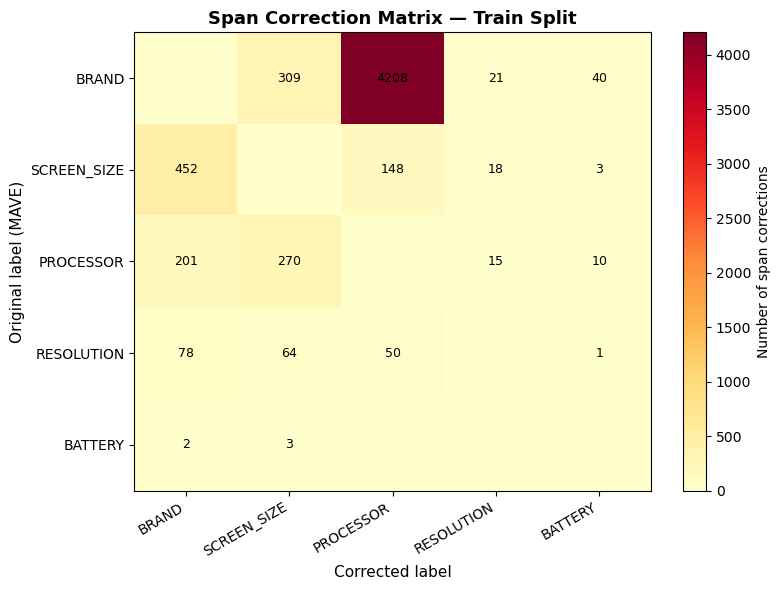

In [ ]:
# ── Span correction heatmap (train) ───────────────────────────────────────
log = all_results['train']['log']
change_counter = Counter(
    (e['orig_label'], e['new_label'])
    for e in log if e['changed'] and e['new_label'] is not None
)

matrix = np.zeros((len(ENTITY_CLASSES), len(ENTITY_CLASSES)), dtype=int)
for (orig, new), cnt in change_counter.items():
    if orig in ENTITY_CLASSES and new in ENTITY_CLASSES:
        matrix[ENTITY_CLASSES.index(orig), ENTITY_CLASSES.index(new)] = cnt

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Number of span corrections')
ax.set_xticks(range(len(ENTITY_CLASSES)))
ax.set_yticks(range(len(ENTITY_CLASSES)))
ax.set_xticklabels(ENTITY_CLASSES, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ENTITY_CLASSES, fontsize=10)
ax.set_xlabel('Corrected label', fontsize=11)
ax.set_ylabel('Original label (MAVE)', fontsize=11)
ax.set_title('Span Correction Matrix — Train Split', fontsize=13, fontweight='bold')
for i in range(len(ENTITY_CLASSES)):
    for j in range(len(ENTITY_CLASSES)):
        if matrix[i, j] > 0:
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('span_correction_matrix_train.png', dpi=150, bbox_inches='tight')
plt.show()
sys.stdout.flush()

The correction matrix makes the dominant noise pattern immediately visible: 4,208 spans were corrected from `BRAND` → `PROCESSOR` — by far the largest single correction, accounting for more than half of all changes in the training split. This confirms quantitatively what the EDA identified qualitatively: the systematic conflation of Intel processor tokens with the `BRAND` class is the primary source of annotation noise in the dataset.

The second largest correction is `SCREEN_SIZE` → `BRAND` (452 spans), which reflects cases where product model identifiers containing size-like strings were mislabelled as screen sizes. `PROCESSOR` → `SCREEN_SIZE` (270 spans) and `PROCESSOR` → `BRAND` (201 spans) represent smaller but consistent noise patterns.

`BATTERY` and `RESOLUTION` are rarely involved in corrections — consistent with their low span counts in the dataset. The near-empty rows for these classes confirm that the pipeline's limited trusted corpus support for `BATTERY` and `RESOLUTION` did not cause spurious corrections.

# Part 3 - Post-Cleaning EDA

This section compares the original and cleaned training splits across the same dimensions analysed in Notebook 01. The goal is to quantify the effect of the RAG-assisted cleaning pipeline — which corrections were applied, which noise patterns were resolved, and where residual limitations remain. All comparisons use the training split, which contains the largest number of spans and provides the most statistically stable estimates.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
from collections import Counter, defaultdict

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = '/Users/asiagrillo/Desktop/MAVE/'
ORIG_PATH  = DATA_DIR + 'laptops_train.jsonl'
CLEAN_PATH = DATA_DIR + 'laptops_train_rag_cleaned.jsonl'

ENTITY_CLASSES = ['BRAND', 'SCREEN_SIZE', 'PROCESSOR', 'RESOLUTION', 'BATTERY']

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
COLORS = {
    'blue':   '#56B4E9',
    'orange': '#E69F00',
    'green':  '#009E73',
    'pink':   '#CC79A7',
    'dblue':  '#0072B2',
    'red':    '#D55E00',
}
CLASS_COLORS = [COLORS['blue'], COLORS['orange'], COLORS['green'],
                COLORS['pink'], COLORS['dblue']]

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

def extract_entities(tokens, labels):
    entities = []
    current_type, current_tokens = None, []
    for tok, lab in zip(tokens, labels):
        if lab.startswith('B-'):
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type = lab[2:]; current_tokens = [tok]
        elif lab.startswith('I-') and current_type:
            current_tokens.append(tok)
        else:
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type, current_tokens = None, []
    if current_type:
        entities.append((current_type, ' '.join(current_tokens)))
    return entities

def span_counts(data):
    counts = {cls: 0 for cls in ENTITY_CLASSES}
    for r in data:
        for lab in r['labels']:
            if lab.startswith('B-'):
                cls = lab[2:]
                if cls in counts:
                    counts[cls] += 1
    return counts

train_orig  = load_jsonl(ORIG_PATH)
train_clean = load_jsonl(CLEAN_PATH)

orig_counts  = span_counts(train_orig)
clean_counts = span_counts(train_clean)

print('Loaded original and cleaned train splits.')
print(f'Original:  {len(train_orig):,} sequences')
print(f'Cleaned:   {len(train_clean):,} sequences')

Loaded original and cleaned train splits.
Original:  7,479 sequences
Cleaned:   7,479 sequences


## 16) Entity Span Count: Original vs Cleaned

In [ ]:
def count_spans(data):
    counts = Counter()
    for ex in data:
        for lab in ex['labels']:
            if lab.startswith('B-'):
                counts[lab.split('-')[1]] += 1
    return counts

orig_counts  = count_spans(train_data)
clean_counts = count_spans(all_results['train']['cleaned'])

print('Entity span counts: Original vs Cleaned (train)')
print(f'{"Class":12s}  {"Original":>10s}  {"Cleaned":>10s}  {"Delta":>8s}')
print('-' * 48)
for c in ENTITY_CLASSES:
    d = clean_counts[c] - orig_counts[c]
    print(f'{c:12s}  {orig_counts[c]:10,}  {clean_counts[c]:10,}  {"+" if d>=0 else ""}{d:7,}')
sys.stdout.flush()

Entity span counts: Original vs Cleaned (train)
Class           Original     Cleaned     Delta
------------------------------------------------
BRAND              6,267       1,975   -4,292
SCREEN_SIZE        7,398       7,058     -340
PROCESSOR          4,085       7,565  +  3,480
RESOLUTION           934         690     -244
BATTERY               79         120  +     41


The chart mirrors the entity span count analysis from Notebook 01, showing how the cleaning pipeline redistributes annotation mass across classes. The expected pattern — consistent with the dominant `BRAND` → `PROCESSOR` correction — is a sharp reduction in `BRAND` spans and a corresponding increase in `PROCESSOR` spans.

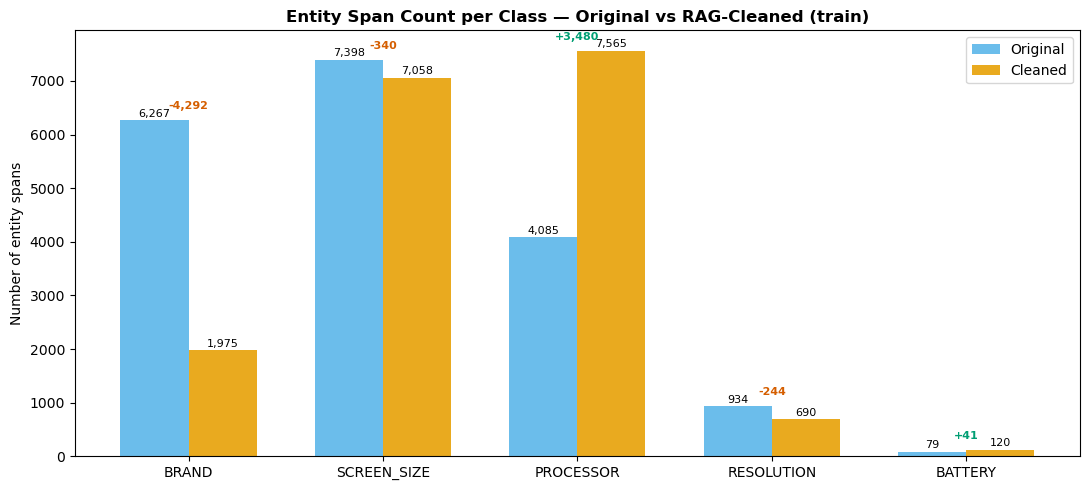

In [ ]:
x     = np.arange(len(ENTITY_CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_orig  = ax.bar(x - width/2,
                    [orig_counts[c]  for c in ENTITY_CLASSES],
                    width, label='Original',  color=COLORS['blue'],   alpha=0.88)
bars_clean = ax.bar(x + width/2,
                    [clean_counts[c] for c in ENTITY_CLASSES],
                    width, label='Cleaned',   color=COLORS['orange'], alpha=0.88)

for bar in bars_orig:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars_clean:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# Delta annotations
for i, cls in enumerate(ENTITY_CLASSES):
    delta = clean_counts[cls] - orig_counts[cls]
    color = COLORS['green'] if delta > 0 else COLORS['red']
    ax.text(i, max(orig_counts[cls], clean_counts[cls]) + 200,
            f'{delta:+,}', ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ENTITY_CLASSES)
ax.set_ylabel('Number of entity spans')
ax.set_title('Entity Span Count per Class — Original vs RAG-Cleaned (train)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('04_span_counts_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

The results confirm the expected redistribution. `BRAND` loses 4,292 spans (from 6,267 to 1,975), while `PROCESSOR` gains 3,480 (from 4,085 to 7,565) — the two deltas are nearly equal in magnitude, directly reflecting the `BRAND` → `PROCESSOR` corrections that dominate the pipeline output. `SCREEN_SIZE` loses 340 spans, consistent with the rule-based reassignment of size-like strings that were incorrectly labelled as screen sizes. `RESOLUTION` loses 244 spans, and `BATTERY` gains a modest 41.

After cleaning, `PROCESSOR` becomes the most frequent entity class, overtaking `SCREEN_SIZE` — a reversal of the original ranking that reflects the correction of years of systematic mislabelling of processor tokens as brand entities.

## 17) BRAND Token Distrubutions: Original vs Cleaned

This chart mirrors the BRAND analysis from Notebook 01, Section 6. The expected effect of cleaning is the disappearance of processor tokens from the `BRAND` distribution — replaced by genuine laptop manufacturer names. However, a structural limitation of the pipeline must be kept in mind: it operates exclusively on existing annotated spans and cannot introduce new annotations on tokens labelled `O` in the original data.

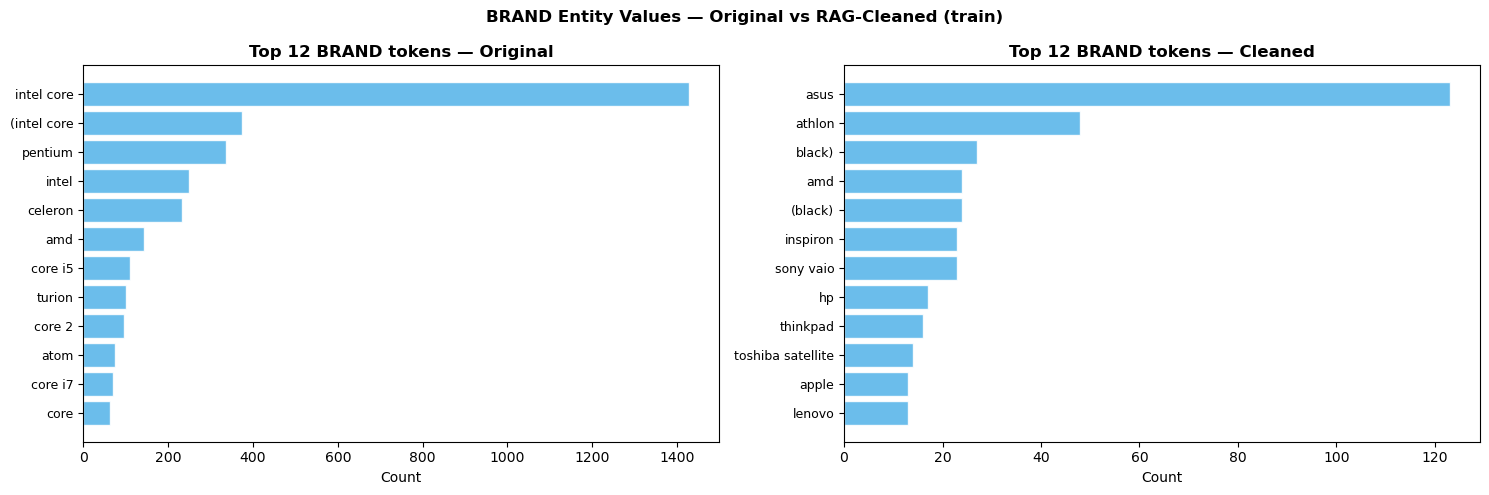


→ Observation: processor tokens (Intel Core, Pentium, Celeron) disappear from BRAND
  after cleaning. However, real laptop brands (Dell, HP, Lenovo) remain absent
  because they were labelled O in the original data — outside the scope of span correction.


In [ ]:
def top_tokens_for_class(data, cls, n=12):
    counter = Counter()
    for r in data:
        for etype, val in extract_entities(r['tokens'], r['labels']):
            if etype == cls:
                counter[val.lower()] += 1
    return counter.most_common(n)

brand_orig  = top_tokens_for_class(train_orig,  'BRAND', 12)
brand_clean = top_tokens_for_class(train_clean, 'BRAND', 12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, data, title in zip(
    axes,
    [brand_orig, brand_clean],
    ['Top 12 BRAND tokens — Original', 'Top 12 BRAND tokens — Cleaned']
):
    vals = [v for v, _ in data]
    cnts = [c for _, c in data]
    ax.barh(vals[::-1], cnts[::-1], color=COLORS['blue'], edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('BRAND Entity Values — Original vs RAG-Cleaned (train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_brand_tokens_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n→ Observation: processor tokens (Intel Core, Pentium, Celeron) disappear from BRAND')
print('  after cleaning. However, real laptop brands (Dell, HP, Lenovo) remain absent')
print('  because they were labelled O in the original data — outside the scope of span correction.')

The before/after comparison is striking. In the original distribution, the top 12 `BRAND` values are dominated by processor descriptors — `"intel core"` alone appears 1,421 times, followed by `"(intel core"`, `"pentium"`, `"intel"`, and `"celeron"`. After cleaning, all processor tokens have been removed from the `BRAND` class and the distribution now reflects genuine brand-like entries: `"asus"`, `"athlon"`, `"sony vaio"`, `"hp"`, `"thinkpad"`, `"apple"`, `"lenovo"`.

However, the structural limitation is equally visible: major laptop manufacturers such as *Dell*, *HP*, and *Lenovo* appear with very low counts (under 20) even in the cleaned version, because they were labelled `O` in the original annotations. The pipeline cannot correct what was never annotated — this is not a failure of the cleaning approach but a fundamental constraint of span-level correction on an incompletely annotated dataset. The implication for model evaluation is discussed in Notebooks 03 and 04: `BRAND` F1 will remain depressed even after cleaning, because the evaluation set rewards the original annotation artifacts.

## 18) PROCESSOR Token Distributions: Original vs Cleaned

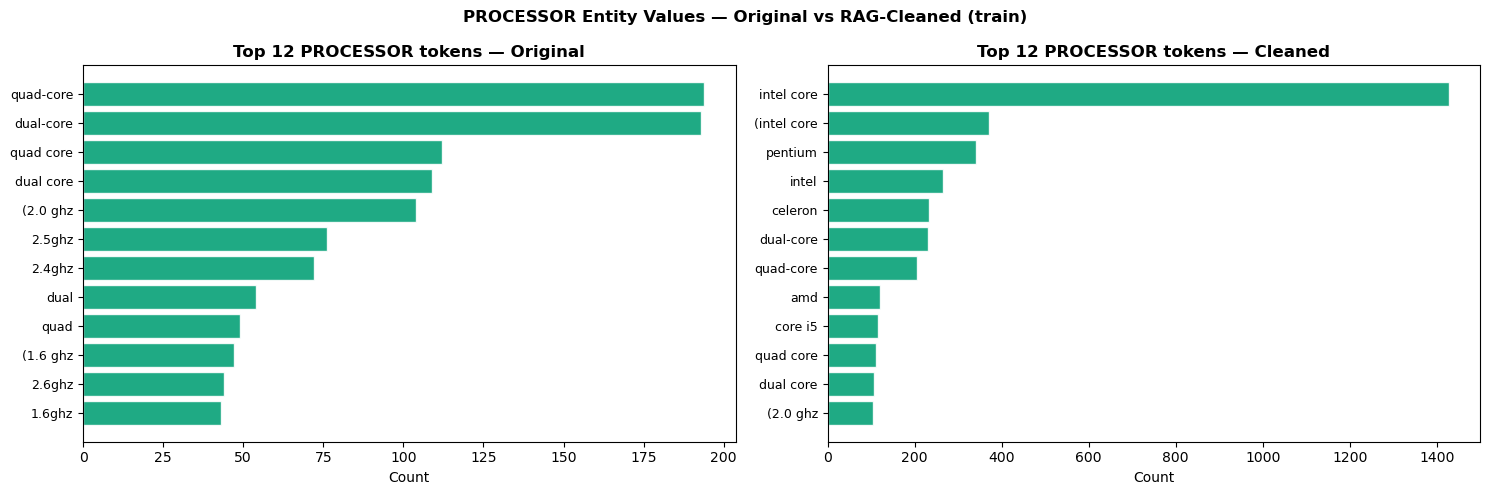


→ Observation: Intel Core, Celeron, Pentium, Atom now appear prominently in PROCESSOR
  after being moved from BRAND. The processor class is more semantically coherent.


In [ ]:
proc_orig  = top_tokens_for_class(train_orig,  'PROCESSOR', 12)
proc_clean = top_tokens_for_class(train_clean, 'PROCESSOR', 12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, data, title in zip(
    axes,
    [proc_orig, proc_clean],
    ['Top 12 PROCESSOR tokens — Original', 'Top 12 PROCESSOR tokens — Cleaned']
):
    vals = [v for v, _ in data]
    cnts = [c for _, c in data]
    ax.barh(vals[::-1], cnts[::-1], color=COLORS['green'], edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('PROCESSOR Entity Values — Original vs RAG-Cleaned (train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_processor_tokens_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n→ Observation: Intel Core, Celeron, Pentium, Atom now appear prominently in PROCESSOR')
print('  after being moved from BRAND. The processor class is more semantically coherent.')

The PROCESSOR distribution shows the mirror image of the BRAND correction. In the original data, the top entries are architecture descriptors such as `"quad-core"`, `"dual-core"`, and clock speed values (`"2.5ghz"`, `"2.4ghz"`) — tokens that describe processor characteristics but not processor identity. After cleaning, `"intel core"` becomes the dominant entry by a large margin (1,421 occurrences), followed by `"(intel core"`, `"pentium"`, `"intel"`, and `"celeron"` — the exact tokens that were removed from the `BRAND` class in Section 11.2.

The cleaned `PROCESSOR` distribution is semantically more coherent: it now contains both manufacturer/family names and architecture descriptors, reflecting the full range of processor-related information present in laptop product titles. This complementary shift between `BRAND` and `PROCESSOR` is the clearest evidence that the pipeline is correcting a genuine annotation error rather than introducing new noise.

## 19) RESOLUTION Surface from Variability: Original vs Cleaned

RESOLUTION unique surface forms — Original: 474 | Cleaned: 266


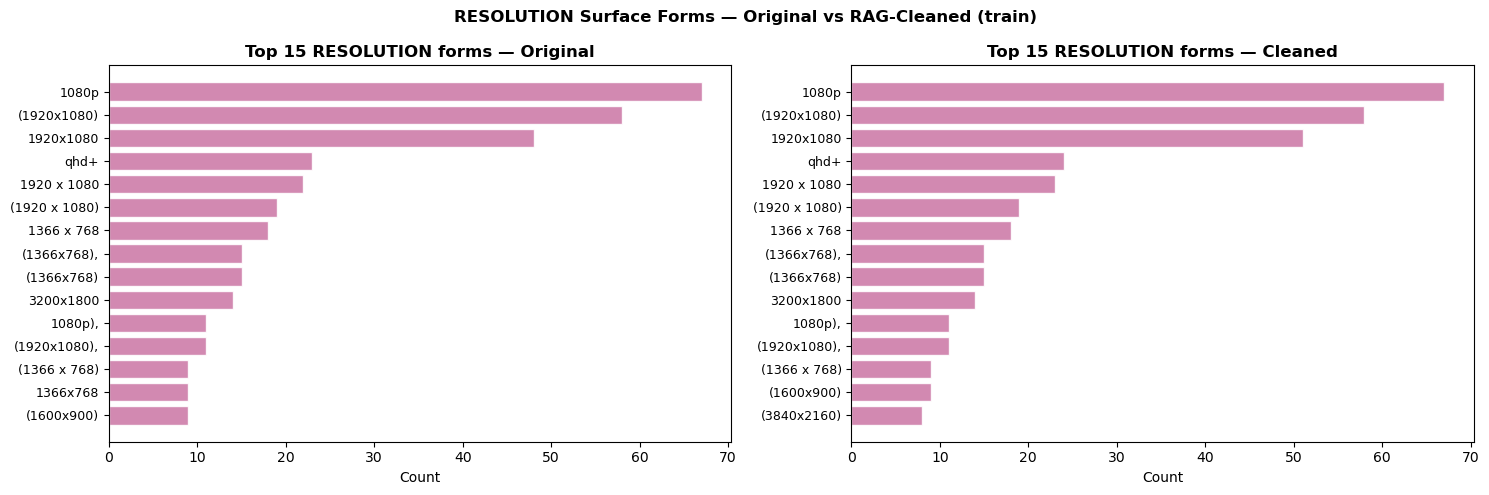

In [ ]:
res_orig  = Counter(v.lower() for r in train_orig
                    for et, v in extract_entities(r['tokens'], r['labels']) if et == 'RESOLUTION')
res_clean = Counter(v.lower() for r in train_clean
                    for et, v in extract_entities(r['tokens'], r['labels']) if et == 'RESOLUTION')

print(f'RESOLUTION unique surface forms — Original: {len(res_orig)} | Cleaned: {len(res_clean)}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, counter, title in zip(
    axes,
    [res_orig, res_clean],
    ['Top 15 RESOLUTION forms — Original', 'Top 15 RESOLUTION forms — Cleaned']
):
    top = counter.most_common(15)
    vals = [v for v, _ in top]
    cnts = [c for _, c in top]
    ax.barh(vals[::-1], cnts[::-1], color=COLORS['pink'], edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('RESOLUTION Surface Forms — Original vs RAG-Cleaned (train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_resolution_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

The number of unique `RESOLUTION` surface forms drops from 474 to 266 after cleaning — a reduction of 43.9%. This confirms that the pipeline successfully merged a significant portion of the long tail of near-duplicate resolution variants, collapsing forms such as `"(1920x1080)"`, `"1920 x 1080"`, and `"1080p)"` into fewer canonical representations.

However, the top 15 distributions remain visually similar: `"1080p"`, `"(1920x1080)"`, and `"1920x1080"` still appear as separate entries with comparable counts, indicating that the most frequent surface form variants were not fully normalised. This is expected — the pipeline resolves label assignment ambiguities but does not perform surface form normalisation, which would require a separate preprocessing step. The lexical variability problem identified in Notebook 01 is therefore only partially addressed by cleaning alone, which further motivates the RESOLUTION normalisation gazetteer explored as a preprocessing step in Notebook 04.

## 20) BATTERY Support: Original vs Cleaned

BATTERY spans — Original: 79 | Cleaned: 120
BATTERY unique forms — Original: 46 | Cleaned: 61


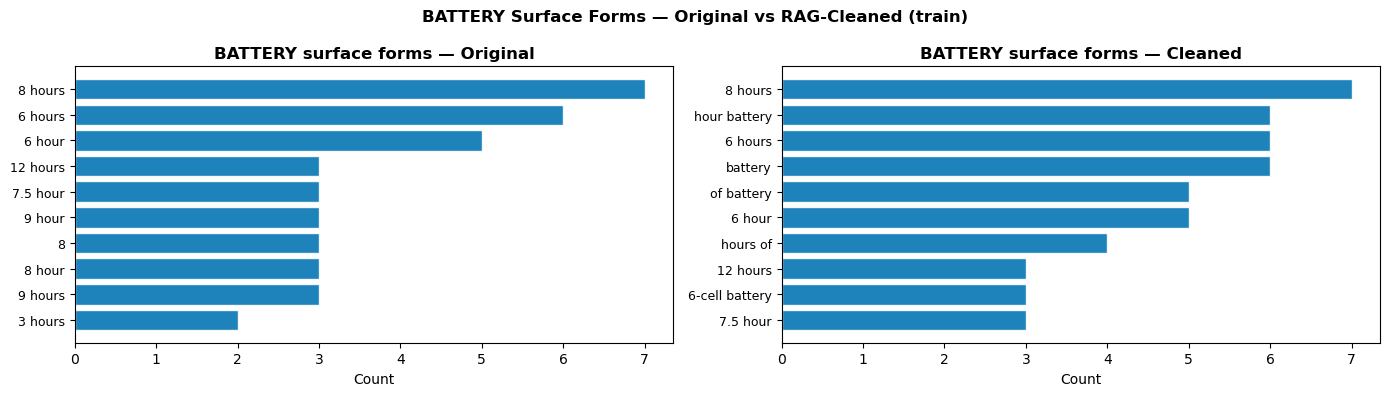


→ BATTERY spans increased by 41 after cleaning.


In [ ]:
bat_orig  = Counter(v.lower() for r in train_orig
                    for et, v in extract_entities(r['tokens'], r['labels']) if et == 'BATTERY')
bat_clean = Counter(v.lower() for r in train_clean
                    for et, v in extract_entities(r['tokens'], r['labels']) if et == 'BATTERY')

print(f'BATTERY spans — Original: {sum(bat_orig.values())} | Cleaned: {sum(bat_clean.values())}')
print(f'BATTERY unique forms — Original: {len(bat_orig)} | Cleaned: {len(bat_clean)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counter, title in zip(
    axes,
    [bat_orig, bat_clean],
    ['BATTERY surface forms — Original', 'BATTERY surface forms — Cleaned']
):
    top = counter.most_common(10)
    vals = [v for v, _ in top]
    cnts = [c for _, c in top]
    ax.barh(vals[::-1], cnts[::-1], color=COLORS['dblue'], edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('BATTERY Surface Forms — Original vs RAG-Cleaned (train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_battery_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n→ BATTERY spans increased by {sum(bat_clean.values()) - sum(bat_orig.values())} after cleaning.')

`BATTERY` spans increase from 79 to 120 after cleaning — a gain of 41 spans (51.9%). This is a meaningful relative improvement given the extreme scarcity of the class, though the absolute support remains critically low.

However, the cleaned distribution reveals a new problem: entries such as `"hour battery"`, `"battery"`, `"of battery"`, and `"hours of"` appear in the top 10, suggesting that the pipeline introduced some noisy `BATTERY` spans by incorrectly extending boundaries or reassigning generic context tokens. These forms are not valid battery descriptors — `"of battery"` and `"hours of"` are clearly boundary artifacts where the span includes surrounding prepositions rather than the battery value itself.

This indicates that the LLM fallback, when resolving ambiguous spans near battery-related tokens, occasionally over-generates `BATTERY` labels. Given the very limited trusted corpus support for this class (only 5 manual seed entries), the retrieved examples may not have been specific enough to constrain the LLM decision reliably. `BATTERY` results in the downstream modelling experiments should therefore be interpreted with extra caution for the cleaned dataset.

## 21) Token Frequency per Class: Original vs Cleaned

This chart mirrors the token frequency analysis from Notebook 01, Section 9, showing the most frequent tokens per entity class before and after cleaning. It provides a consolidated view of the distributional shifts across all five classes simultaneously.

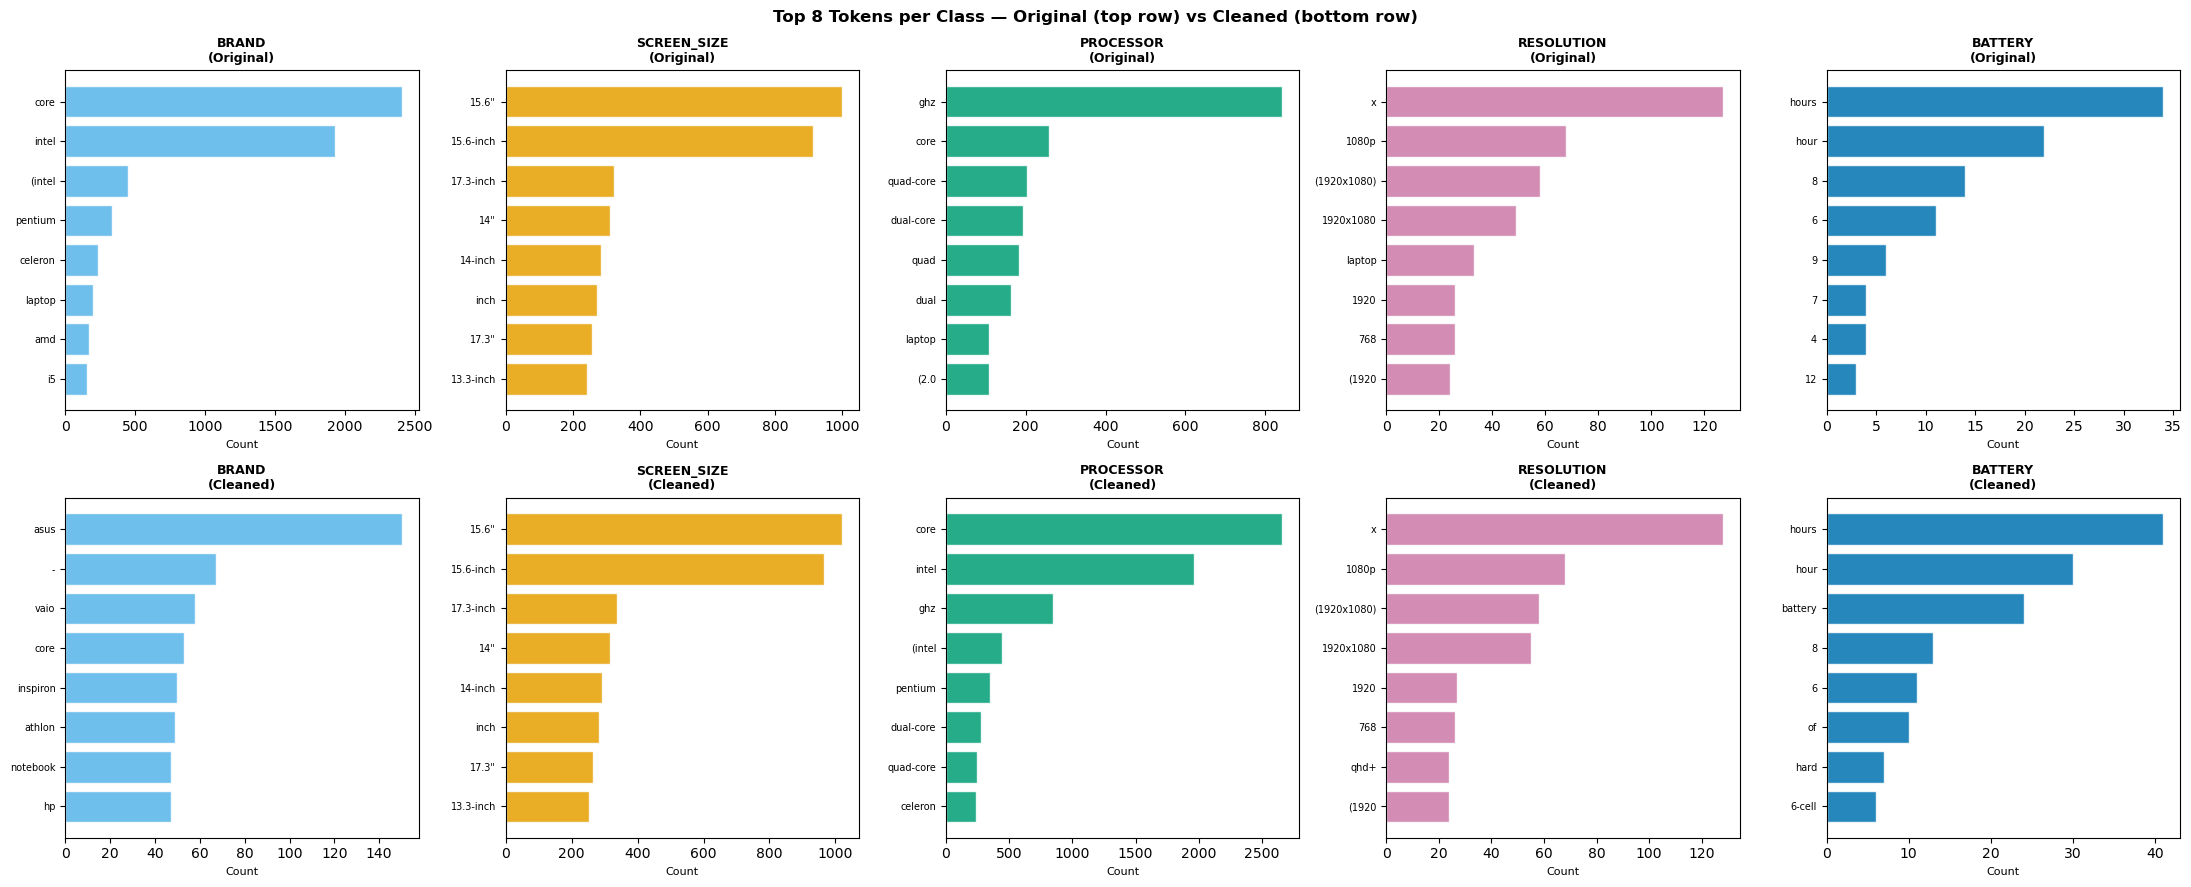

In [ ]:
def token_freq_per_class(data):
    class_tokens = defaultdict(list)
    for r in data:
        for tok, lab in zip(r['tokens'], r['labels']):
            if lab != 'O':
                cls = lab.split('-')[1]
                class_tokens[cls].append(tok.lower())
    return {cls: Counter(toks) for cls, toks in class_tokens.items()}

freq_orig  = token_freq_per_class(train_orig)
freq_clean = token_freq_per_class(train_clean)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for col, (data_freq, label) in enumerate([(freq_orig, 'Original'), (freq_clean, 'Cleaned')]):
    for row, cls in enumerate(ENTITY_CLASSES):
        ax = axes[col][row]
        top = data_freq.get(cls, Counter()).most_common(8)
        if not top:
            ax.set_visible(False); continue
        toks = [t for t, _ in top]
        cnts = [c for _, c in top]
        ax.barh(toks[::-1], cnts[::-1], color=CLASS_COLORS[row], edgecolor='white', alpha=0.85)
        ax.set_title(f'{cls}\n({label})', fontsize=9, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.set_xlabel('Count', fontsize=8)

plt.suptitle('Top 8 Tokens per Class — Original (top row) vs Cleaned (bottom row)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_token_freq_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

The grid confirms the patterns observed in the individual class analyses. The most visible shift is in `BRAND` and `PROCESSOR`: the original `BRAND` row is dominated by `"core"` and `"intel"` (processor tokens), while in the cleaned version `"asus"` leads and the top entries are genuine brand-related strings. Correspondingly, `"core"` and `"intel"` move to the top of the `PROCESSOR` column after cleaning, where they belong semantically.

`SCREEN_SIZE` and `RESOLUTION` show minimal changes, consistent with the observation that these classes were less affected by the dominant correction pattern. The `BATTERY` column reveals the noise introduced by the pipeline: `"battery"` and `"of"` appear as new top tokens in the cleaned version — short context tokens that were incorrectly absorbed into `BATTERY` spans during the LLM fallback, as noted in Section 11.5.

`SCREEN_SIZE` is the most stable class across both versions, with an identical top-8 ranking — confirming that the cleaning pipeline left this well-annotated class largely untouched.

## 22) Cleaning Pipeline: Limitations and Methodological Implications

The RAG-assisted cleaning pipeline successfully addresses the dominant annotation error in the MAVE Laptops dataset: the systematic mislabelling of processor tokens (`"intel core"`, `"celeron"`, `"pentium"`, `"atom"`) as `BRAND`. Across all three splits, 47–57% of ambiguous spans were corrected, with `BRAND` → `PROCESSOR` accounting for the majority of changes.

Two residual limitations were identified during the post-cleaning analysis:

**1. Incomplete BRAND recovery.** The pipeline operates exclusively on existing annotated spans. Real laptop manufacturers such as *Dell*, *HP*, and *Lenovo* were labelled `O` in the original annotations and therefore remain unlabelled after cleaning — the pipeline cannot introduce new spans on tokens that carry no annotation. A dedicated span detection phase scanning `O` tokens against a curated brand gazetteer would be required to recover these missing annotations, but this falls outside the scope of span-level label correction.

**2. Occasional over-correction.** A small number of spans were incorrectly modified by the LLM fallback, particularly for `BATTERY` — where the limited trusted corpus (5 seed entries) did not provide sufficient retrieval evidence to constrain the model reliably. Generic context tokens such as `"of"` and `"battery"` were occasionally absorbed into `BATTERY` spans as boundary artifacts.

These limitations have a direct implication for the downstream modelling experiments in Notebooks 03 and 04: models trained on cleaned data are expected to show a drop in `BRAND` F1 when evaluated on the original test set, because the original benchmark still rewards the systematic annotation errors that cleaning has removed. This drop is not a failure of the cleaning approach — it is evidence that the original test set contains the same noise as the training set. The auxiliary evaluation on the cleaned test set (Setting 2) provides the complementary perspective.

## 23) Summary and Next Steps

The RAG-assisted cleaning pipeline processed all three dataset splits, correcting 47–57% of ambiguous spans. The dominant correction pattern — `BRAND` → `PROCESSOR` (4,208 corrections in train) — directly addresses the primary annotation noise identified in the EDA. All cleaned files are saved to disk and ready for the downstream modelling experiments.

**Output files:**
- `laptops_train_rag_cleaned.jsonl` — cleaned training set
- `laptops_val_rag_cleaned.jsonl` — cleaned validation set
- `laptops_test_rag_cleaned.jsonl` — cleaned test set (auxiliary analysis only)

**Evaluation settings (as defined in Section 1.6):**
- **Setting 1 — Main benchmark**: train on cleaned data, evaluate on original test set — rigorous and conservative
- **Setting 2 — Auxiliary**: train on cleaned data, evaluate on cleaned test set — qualitative support only

**Next steps:**
- **Notebook 03** — BiLSTM + CRF: retrain on cleaned data, evaluate under both settings
- **Notebook 04** — DeBERTa-v3-base: retrain on cleaned data, evaluate under both settings

If gains in Setting 1 are modest, the correct interpretation is that they are underestimated due to residual label noise in the original evaluation split — the auxiliary setting provides the complementary evidence.